In [1]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\FBS\Data Analysis\Project\cardekho_dataset.csv')

In [4]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.shape




(15411, 14)

In [6]:
df.shape[1]#no.columns

14

In [7]:
#no.of rows
df.shape[0]

15411

In [8]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [10]:
#missing value
df.isna().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [11]:
sns.set_theme(style="whitegrid")

Text(0, 0.5, 'Count')

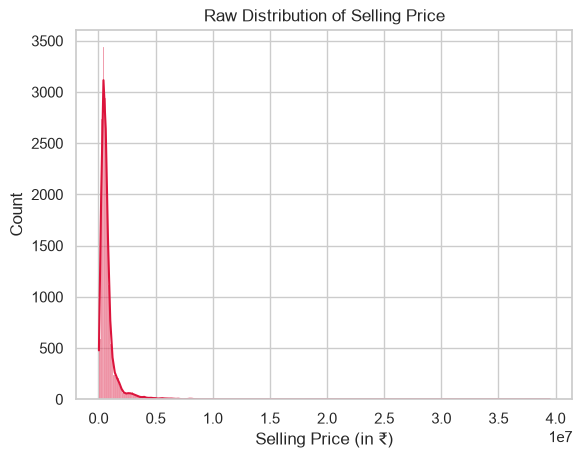

In [12]:
# Plot 1: Raw Selling Price Distribution (Checking for extreme luxury outliers)
sns.histplot(df['selling_price'], kde=True, color='crimson')
plt.title('Raw Distribution of Selling Price')
plt.xlabel('Selling Price (in ₹)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

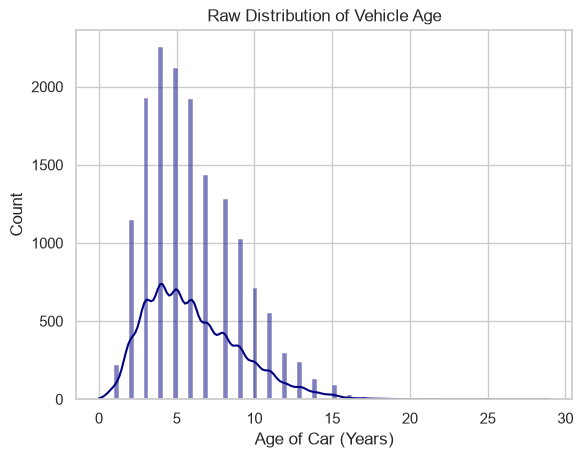

In [13]:
# Plot 2: Raw Vehicle Age Distribution
sns.histplot(df['vehicle_age'], kde=True, color='navy')
plt.title('Raw Distribution of Vehicle Age')
plt.xlabel('Age of Car (Years)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

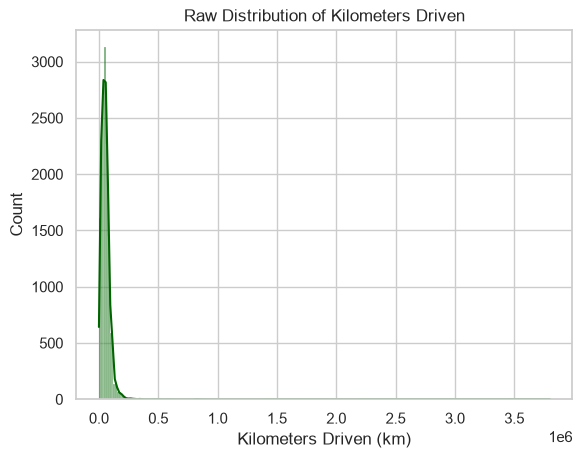

In [14]:
sns.histplot(df['km_driven'], kde=True, color='darkgreen')
plt.title('Raw Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven (km)')
plt.ylabel('Count')

In [15]:
top_brands = df['brand'].value_counts().head(15)

In [16]:
top_brands


brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Maruti'),
  Text(1, 0, 'Hyundai'),
  Text(2, 0, 'Honda'),
  Text(3, 0, 'Mahindra'),
  Text(4, 0, 'Toyota'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Volkswagen'),
  Text(7, 0, 'Renault'),
  Text(8, 0, 'BMW'),
  Text(9, 0, 'Tata'),
  Text(10, 0, 'Mercedes-Benz'),
  Text(11, 0, 'Skoda'),
  Text(12, 0, 'Audi'),
  Text(13, 0, 'Datsun'),
  Text(14, 0, 'Jaguar')])

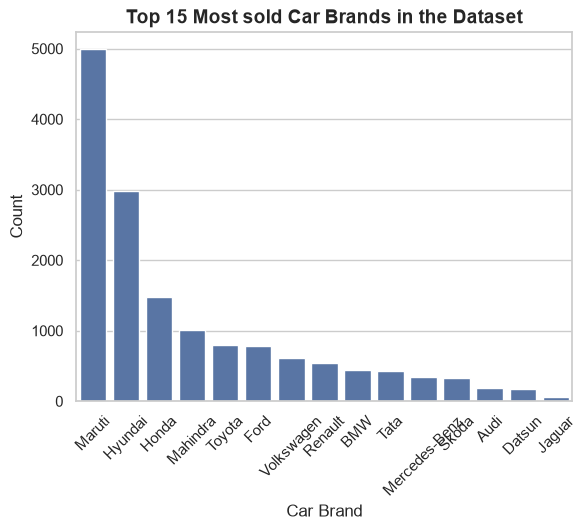

In [17]:
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title('Top 15 Most sold Car Brands in the Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Car Brand', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

In [18]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Text(0.5, 1.0, 'Proportional Distribution of Vehicles by Fuel Type')

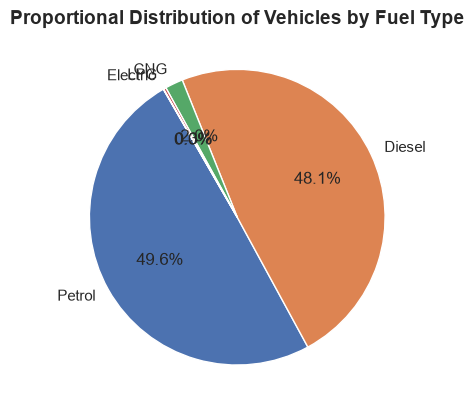

In [19]:
# Calculate the count of each fuel type
fuel_counts = df['fuel_type'].value_counts()

# Create the pie chart
plt.pie(
    fuel_counts.values, 
    labels=fuel_counts.index, 
    autopct='%1.1f%%',       # This displays the percentage on each slice
    startangle=120          # Rotates the start point for a cleaner look
)

plt.title('Proportional Distribution of Vehicles by Fuel Type', fontsize=14, fontweight='bold')

Text(0.5, 19.71216362847222, 'Selling Price (in ₹)')

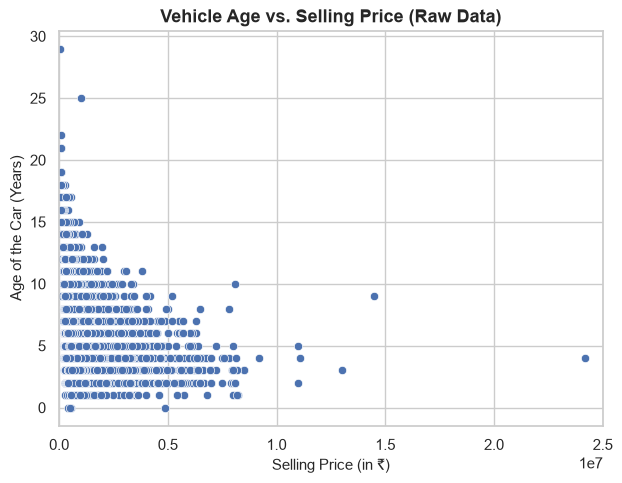

In [20]:
# Plot 1: Vehicle Age vs Selling Price (Normal Scatter 

sns.scatterplot(data= df ,x='selling_price', y='vehicle_age', color='b')
plt.xlim(0,25000000) # Limit to 25 lakhs Rupees to view clean
plt.tight_layout()

plt.title('Vehicle Age vs. Selling Price (Raw Data)', fontsize=13, fontweight='bold')
plt.ylabel('Age of the Car (Years)', fontsize=11)
plt.xlabel('Selling Price (in ₹)', fontsize=11)

Text(0, 0.5, 'Selling Price (in ₹)')

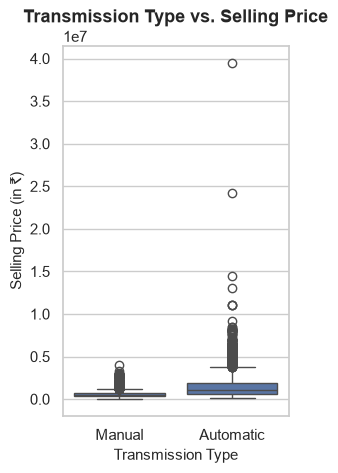

In [21]:
# Plot 2: Transmission Type vs Selling Price (Categorical Relationship)
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df, 
    x='transmission_type', 
    y='selling_price'
)
plt.title('Transmission Type vs. Selling Price', fontsize=13, fontweight='bold')
plt.xlabel('Transmission Type', fontsize=11)
plt.ylabel('Selling Price (in ₹)', fontsize=11)

Text(0.5, 19.71216362847222, 'Selling Price (in ₹)')

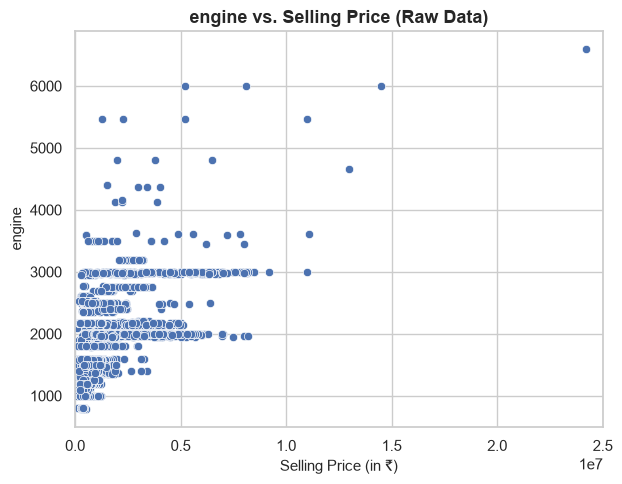

In [22]:
sns.scatterplot(data= df ,x='selling_price', y='engine', color='b')
plt.xlim(0,25000000) # Limit to 25 lakhs Rupees to view clean
plt.tight_layout()

plt.title('engine vs. Selling Price (Raw Data)', fontsize=13, fontweight='bold')
plt.ylabel('engine', fontsize=11)
plt.xlabel('Selling Price (in ₹)', fontsize=11)

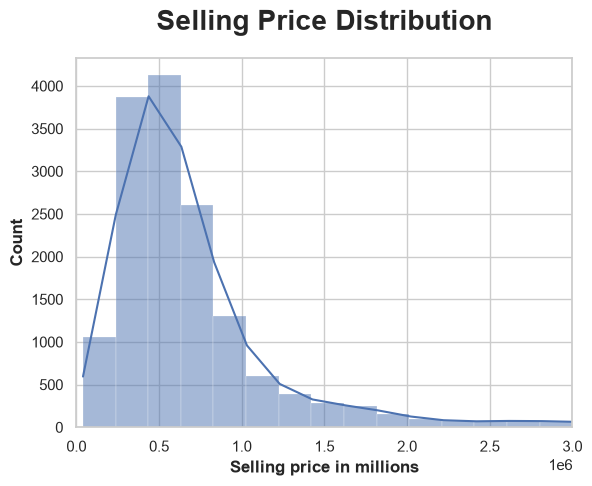

In [23]:

sns.histplot(df.selling_price, bins=200, kde=True, color = 'b')
plt.title("Selling Price Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Selling price in millions", weight="bold", fontsize=12)
plt.xlim(0,3000000)
plt.show()

In [24]:
brand = df.groupby('brand').selling_price.max()
brand = brand.to_frame().sort_values('selling_price',ascending=False)[0:10]

print('-'*50)
print('Top 10 Costlier Brands on CarDekho Website')
print('-'*50)

brand

--------------------------------------------------
Top 10 Costlier Brands on CarDekho Website
--------------------------------------------------


,selling_price
brand,
Ferrari,39500000
Rolls-Royce,24200000
Bentley,14500000
Mercedes-Benz,13000000
Porsche,11100000
Land Rover,9200000
BMW,8500000
Volvo,8195000
Lexus,8000000


C:\Users\pg236\AppData\Local\Temp\ipykernel_15336\2446289997.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand.index, y=brand.selling_price,ec = "black",palette="Set2")


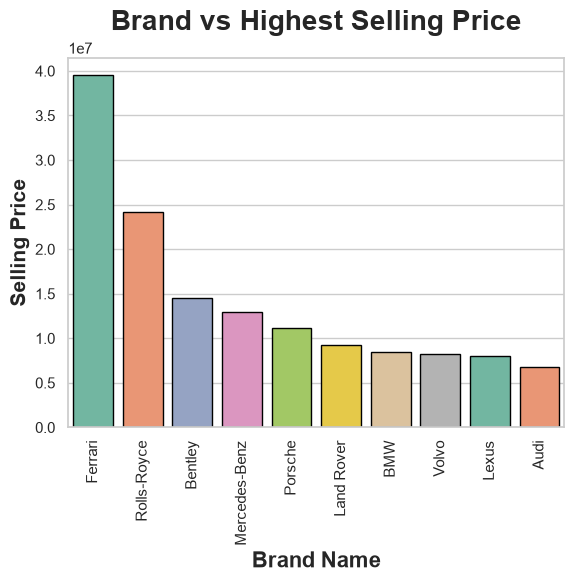

In [25]:
sns.barplot(x=brand.index, y=brand.selling_price,ec = "black",palette="Set2")
plt.title("Brand vs Highest Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Selling Price", weight="bold", fontsize=15)
plt.xlabel("Brand Name", weight="bold", fontsize=16)
plt.xticks(rotation=90)
plt.show()

In [26]:
mileage= df.groupby('brand')['mileage'].mean().sort_values(ascending=False).head(15)

print('-'*50)
print('Most Mileage Car Brand on CarDekho Website')
print('-'*50)

mileage.to_frame()

--------------------------------------------------
Most Mileage Car Brand on CarDekho Website
--------------------------------------------------


,mileage
brand,
Maruti,22.430980
Renault,22.099142
Datsun,21.215647
Lexus,20.846000
Ford,19.922620
Honda,19.908795
Maserati,19.820000
Tata,19.755279
Hyundai,19.588776


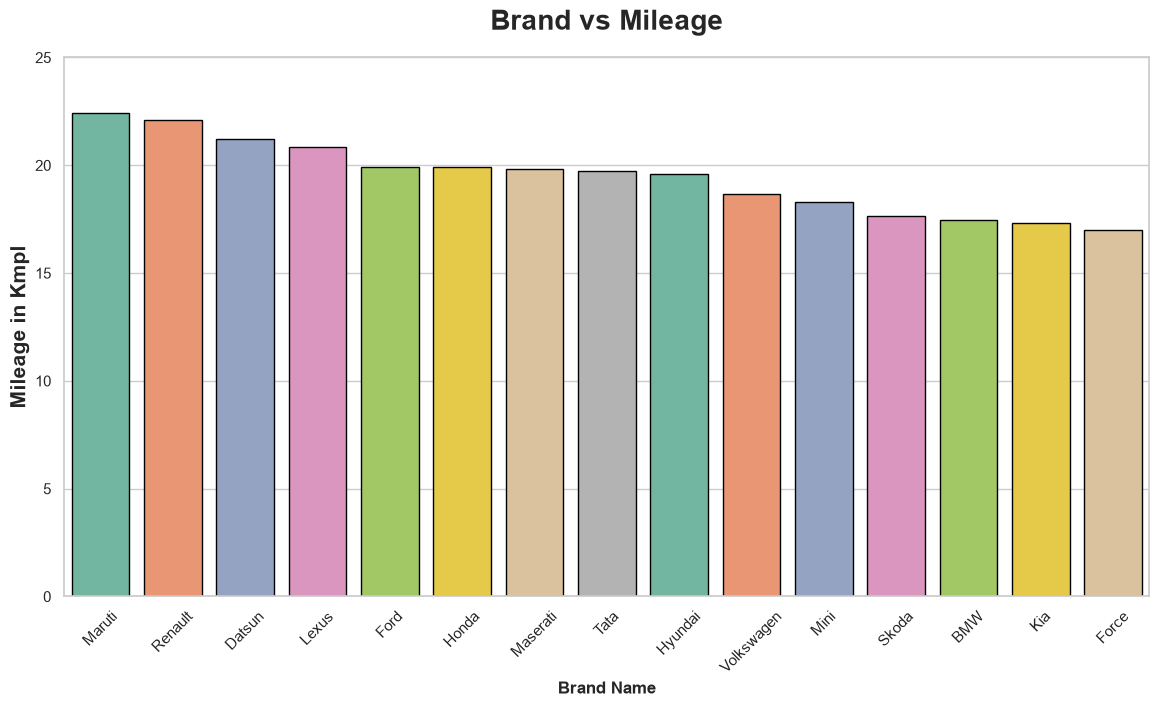

In [27]:
plt.subplots(figsize=(14,7))

sns.barplot(
    x=mileage.index, 
    y=mileage.values, 
    ec="black", 
    palette="Set2", 
    hue=mileage.index, 
    legend=False
)

plt.title("Brand vs Mileage", weight="bold", fontsize=20, pad=20)
plt.ylabel("Mileage in Kmpl", weight="bold", fontsize=15)
plt.xlabel("Brand Name", weight="bold", fontsize=12)
plt.ylim(0, 25)
plt.xticks(rotation=45)
plt.show()

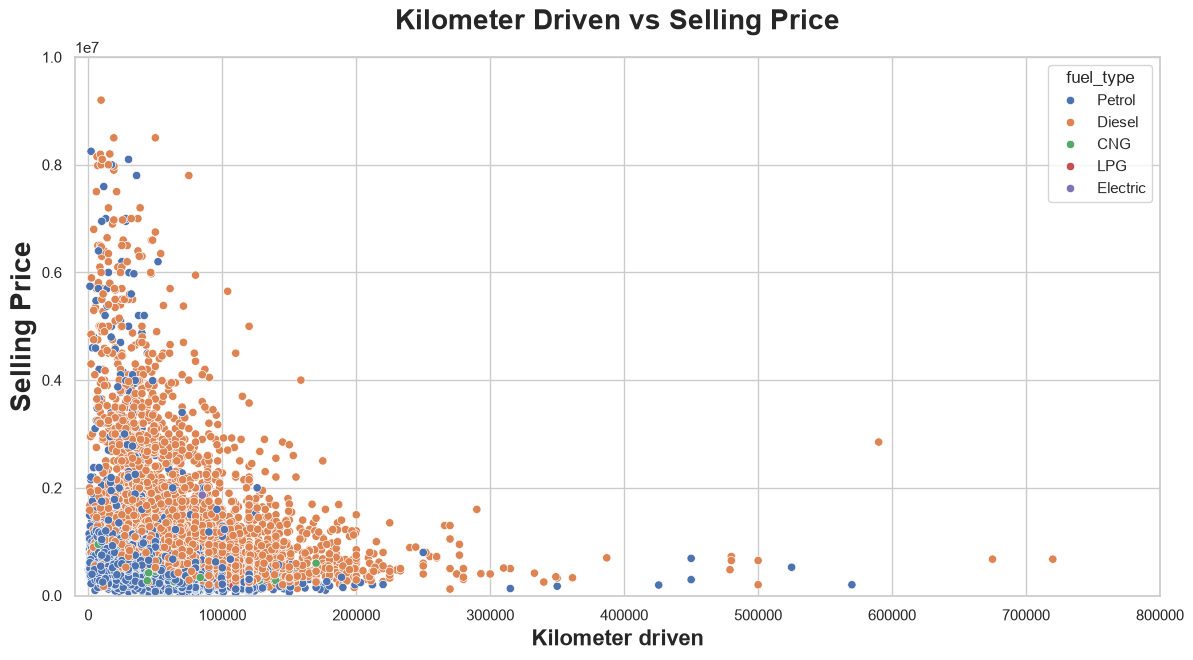

In [28]:
plt.subplots(figsize=(14,7))
sns.scatterplot(x="km_driven", y='selling_price', data=df,ec = "white",color='b', hue='fuel_type')
plt.title("Kilometer Driven vs Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Selling Price", weight="bold", fontsize=20)
plt.xlim(-10000,800000) #used limit for better visualization
plt.ylim(-10000,10000000)
plt.xlabel("Kilometer driven", weight="bold", fontsize=16)
plt.show()

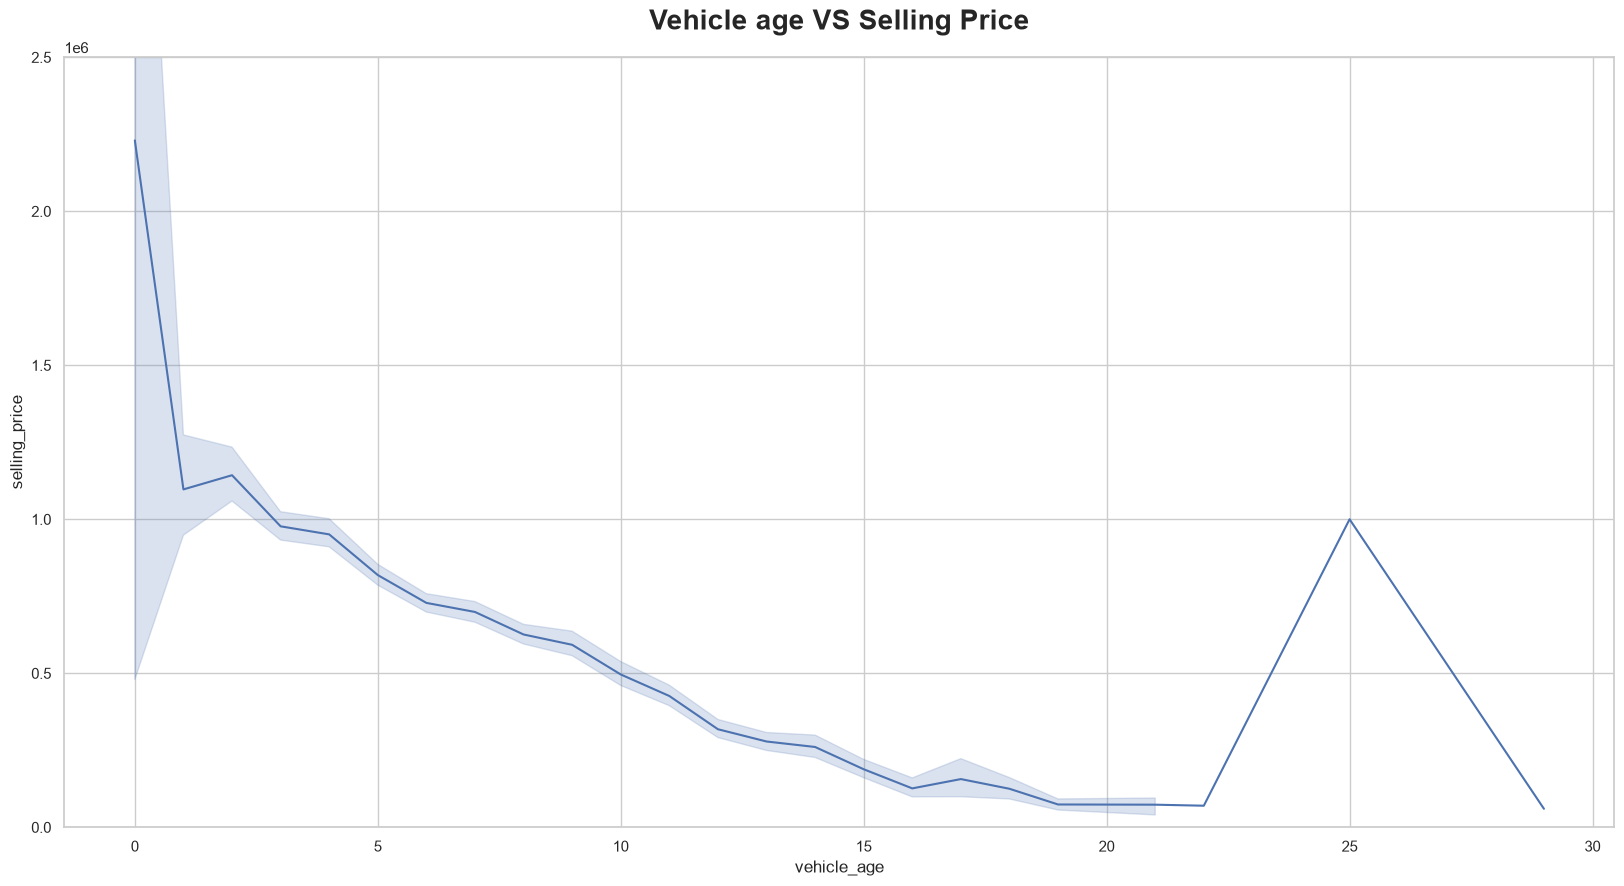

In [29]:
plt.subplots(figsize=(20,10))
sns.lineplot(x='vehicle_age',y='selling_price',data=df,color='b')
plt.ylim(0,2500000)
plt.title("Vehicle age VS Selling Price",weight="bold",fontsize=20, pad=20)
plt.show()

In [30]:
# Creating copy of  original dataframe

df_model=df.copy()

df_model

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [31]:
#drop name-based text with too many unique values to keep the model stable
df_model.drop(labels=['car_name','brand','model'],axis=1,inplace=True)

df_model

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [32]:
df_model=pd.get_dummies(df_model,drop_first=True,dtype=float)

In [33]:
df_model.head()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,120000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1,5,20000,18.90,1197,82.00,5,550000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,2,11,60000,17.00,1197,80.00,5,215000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,3,9,37000,20.92,998,67.10,5,226000,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,4,6,30000,22.77,1498,98.59,5,570000,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop the unnecessary index column
if 'Unnamed: 0' in df_model.columns:
    X = df_model.drop(columns=['selling_price', 'Unnamed: 0'])
else:
    X = df_model.drop(columns=['selling_price'])

y = df_model['selling_price']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale only continuous features (so we don't mess up the 0.0 and 1.0 dummy columns)
numeric_features = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("--- Preprocessing Complete ---")
print("Ready for modeling. Features shape:", X_train_scaled.shape)

--- Preprocessing Complete ---
Ready for modeling. Features shape: (12328, 13)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Extract only 'vehicle_age'
X_train_simple = X_train_scaled[['vehicle_age']]
X_test_simple = X_test_scaled[['vehicle_age']]

# Train
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

# Evaluate
y_pred_simple = simple_model.predict(X_test_simple)
print("=== STAGE 1: SIMPLE LINEAR REGRESSION ===")
print(f"R² Score: {r2_score(y_test, y_pred_simple):.4f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_simple)):.2f}")

=== STAGE 1: SIMPLE LINEAR REGRESSION ===
R² Score: 0.0669
RMSE: ₹838087.60


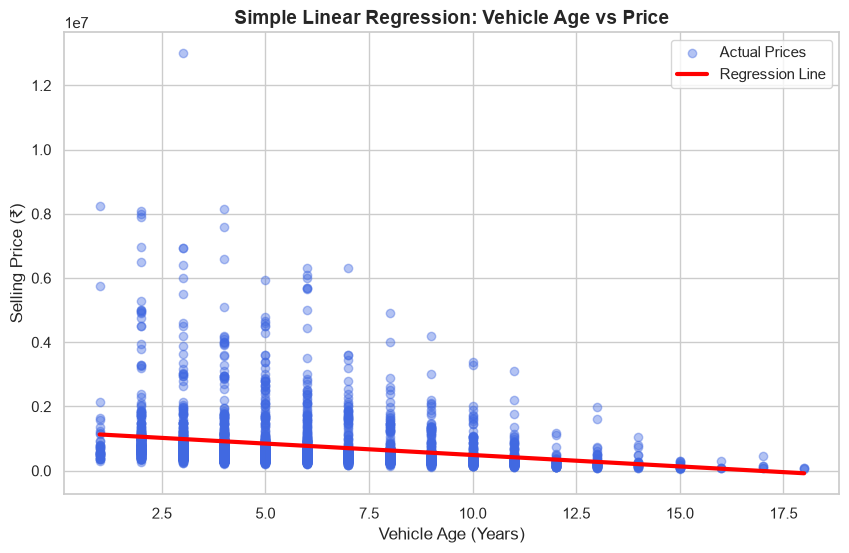

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# 1. Scatter plot of the raw Test Data (Age vs Actual Price)
# We use X_test (unscaled) on the X-axis so the years (1, 2, 3...) make sense on the graph
plt.scatter(X_test['vehicle_age'], y_test, color='royalblue', alpha=0.4, label='Actual Prices')

# 2. Plot the regression line
# To make a clean line, we sort the age values first
sort_axis = np.argsort(X_test['vehicle_age'])
plt.plot(X_test['vehicle_age'].iloc[sort_axis], y_pred_simple[sort_axis], color='red', linewidth=3, label='Regression Line')

plt.title('Simple Linear Regression: Vehicle Age vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Age (Years)', fontsize=12)
plt.ylabel('Selling Price (₹)', fontsize=12)
plt.legend()
plt.show()

In [36]:
# Train using all features
multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_multi = multi_model.predict(X_test_scaled)
print("=== STAGE 2: MULTIPLE LINEAR REGRESSION ===")
print(f"R² Score: {r2_score(y_test, y_pred_multi):.4f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")

=== STAGE 2: MULTIPLE LINEAR REGRESSION ===
R² Score: 0.6651
RMSE: ₹502095.14


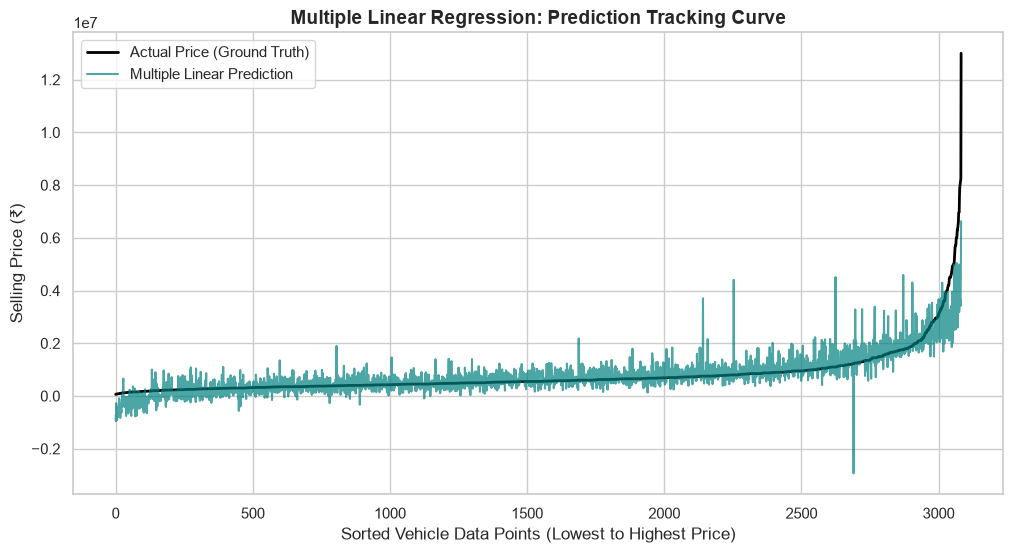

In [41]:
plt.figure(figsize=(12, 6))

# Sort the test data based on actual prices to create a clean, rising curve
sorted_indices = np.argsort(y_test.values)
sorted_actual = y_test.values[sorted_indices]
sorted_pred_multi = y_pred_multi[sorted_indices]

# Plot Actual vs Predicted as lines
plt.plot(sorted_actual, color='black', linewidth=2, label='Actual Price (Ground Truth)')
plt.plot(sorted_pred_multi, color='teal', alpha=0.7, linewidth=1.5, label='Multiple Linear Prediction')

plt.title('Multiple Linear Regression: Prediction Tracking Curve', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Vehicle Data Points (Lowest to Highest Price)', fontsize=12)
plt.ylabel('Selling Price (₹)', fontsize=12)
plt.legend()
plt.show()

In [39]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial interactions
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Evaluate
y_pred_poly = poly_model.predict(X_test_poly)
print("=== STAGE 3: POLYNOMIAL REGRESSION (DEG 2) ===")
print(f"R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")

=== STAGE 3: POLYNOMIAL REGRESSION (DEG 2) ===
R² Score: 0.5602
RMSE: ₹575402.58


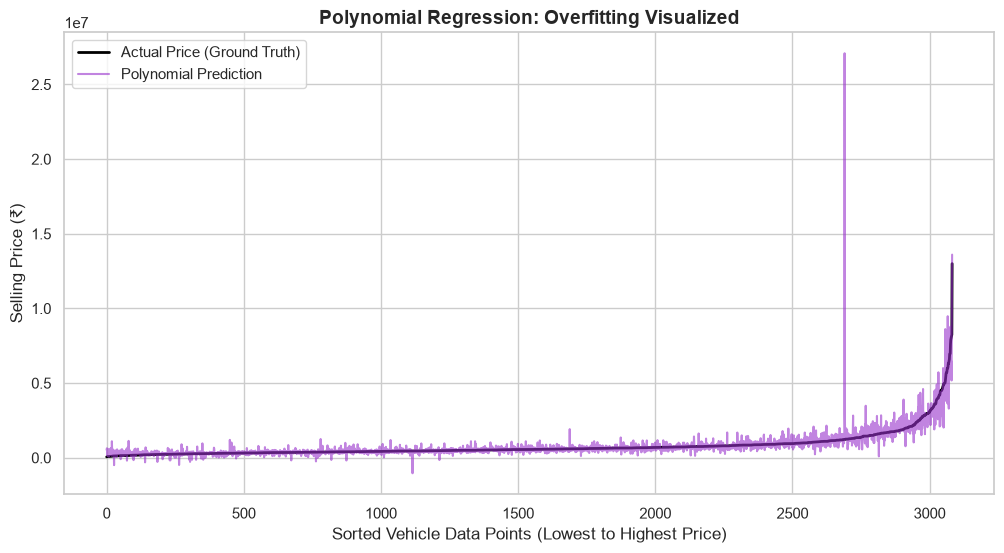

In [42]:
plt.figure(figsize=(12, 6))

# Use the same sorted indices to map the polynomial predictions
sorted_pred_poly = y_pred_poly[sorted_indices]

# Plot Actual vs Polynomial Predicted
plt.plot(sorted_actual, color='black', linewidth=2, label='Actual Price (Ground Truth)')
plt.plot(sorted_pred_poly, color='darkorchid', alpha=0.6, linewidth=1.5, label='Polynomial Prediction')

plt.title('Polynomial Regression: Overfitting Visualized', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Vehicle Data Points (Lowest to Highest Price)', fontsize=12)
plt.ylabel('Selling Price (₹)', fontsize=12)
plt.legend()
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Start fresh with a copy of your cleaned base data
df_filtered = df_model.copy()

# 2. Trim extreme outliers (Trimming the top ~3% luxury spikes)
# This removes the massive price pulling effect from your scatter plots
df_filtered = df_filtered[df_filtered['selling_price'] < 2000000] # Cap at ₹20 Lakhs
df_filtered = df_filtered[df_filtered['km_driven'] < 200000]     # Cap at 2 Lakh kms

# 3. Separate features and target
if 'Unnamed: 0' in df_filtered.columns:
    X = df_filtered.drop(columns=['selling_price', 'Unnamed: 0'])
else:
    X = df_filtered.drop(columns=['selling_price'])
y = df_filtered['selling_price']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the numerical columns
numeric_features = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("--- Outlier Trimming complete ---")
print(f"Remaining dataset rows: {X_train_scaled.shape[0] + X_test_scaled.shape[0]}")

--- Outlier Trimming complete ---
Remaining dataset rows: 14504


In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Create Polynomial Features (Degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# 2. Plain Linear Regression without any Regularization/Penalty
plain_poly_model = LinearRegression()
plain_poly_model.fit(X_train_poly, y_train)

# 3. Predict and Evaluate
y_pred_poly = plain_poly_model.predict(X_test_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== STAGE 3: PLAIN POLYNOMIAL REGRESSION (NO RIDGE) ===")
print(f"R² Score: {r2_poly:.4f}")
print(f"RMSE: ₹{rmse_poly:.2f}")

=== STAGE 3: PLAIN POLYNOMIAL REGRESSION (NO RIDGE) ===
R² Score: 0.8394
RMSE: ₹139626.27


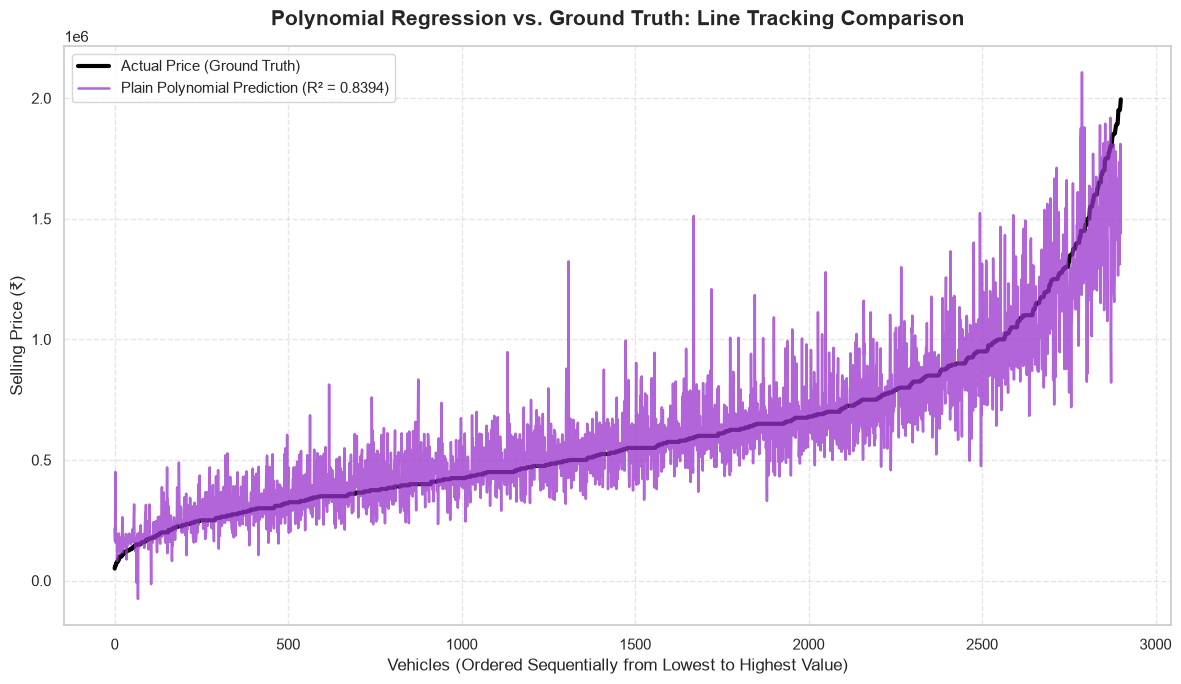

In [58]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# 1. Sort the test data based on actual prices to create a clean rising baseline curve
sorted_indices = np.argsort(y_test.values)
sorted_actual = y_test.values[sorted_indices]
sorted_pred_poly = y_pred_poly[sorted_indices]

# 2. Plot the Actual Prices as a solid baseline line
plt.plot(
    sorted_actual, 
    color='black', 
    linewidth=3, 
    label='Actual Price (Ground Truth)'
)

# 3. Plot the Polynomial Predictions as an overlaying line
plt.plot(
    sorted_pred_poly, 
    color='darkorchid', 
    alpha=0.75, 
    linewidth=1.8, 
    label='Plain Polynomial Prediction (R² = 0.8394)'
)

# 4. Format the presentation layout
plt.title('Polynomial Regression vs. Ground Truth: Line Tracking Comparison', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Vehicles (Ordered Sequentially from Lowest to Highest Value)', fontsize=12)
plt.ylabel('Selling Price (₹)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()